<div style="width: 100%; clear: both;">
    <div style="float: left; width: 50%;">
       <img src="https://www.uoc.edu/portal/system/modules/edu.uoc.presentations/resources/img/branding/logo-uoc-default.png", align="left">
    </div>
</div>

<div style="float: right; width: 50%;">
    <p style="margin: 0; padding-top: 22px; text-align:right;">22.503 · Programación para la ciencia de datos</p>
    <p style="margin: 0; text-align:right;">Grado en Ciencia de Datos Aplicada</p>
    <p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>

</div>
<div style="width: 100%; clear: both;">
<div style="width:100%;">&nbsp;</div>

Programación para la ciencia de datos - PEC4
============================

En este Notebook encontraréis el ejercicio que supone la cuarta y última actividad de evaluación continuada (PEC) de la asignatura. Esta PEC intenta presentaros un pequeño proyecto en el cual debéis resolver diferentes ejercicios, que  engloba muchos de los conceptos cubiertos durante la asignatura.

El objetivo de este ejercicio será desarrollar un **proyecto Python** fuera del entorno de Notebooks, que nos permita resolver el problema dado.
Trabajaréis en archivos Python planos `.py`. Éste tendrá que incluir el correspondiente código organizado lógicamente (separado por módulos, organizados por funcionalidad,...), la documentación del código (*docstrings*) y tests. Además, tendréis que incluir los correspondientes archivos de documentación de alto nivel (`README`) así como los archivos de licencia y dependencias (`requirements.txt`) comentados en la teoría.

Hacer un `setup.py` es opcional, pero si se hace se valorará positivamente de cara a la nota de la práctica y del curso.

# Llga de fútbol 1995-2025

En esta PEC4 analizaremos los datos históricos de la Liga española de fútbol, desde 1995 hasta 2025.
El dataset lo hemos extraído de:

- https://www.kaggle.com/datasets/kishan305/la-liga-results-19952020

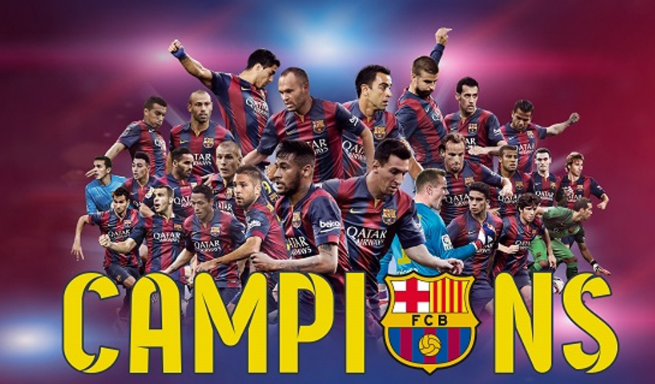


La PEC4 consta de unos 7 primeros ejercicios relacionados con el dataset.

**NOTA**: Estos ejercicios los puedes realizar de forma provisional en un cuaderno de Jupyter, si lo crees
conveniente (por la ventaja de poder ejecutar las celdas individualmente).


Una vez realizados los 7 ejercicios, se deberá dar forma de proyecto Python a todo el código, y estos son los
aspectos que consideramos importantes: trabajar con módulos, generación de documentación, tests, calidad del
código, GitHub, etc. (más información al final).

En el código deberás definir dos variables globales:

`
nom_alumne = "nom_alumne"  # sustituir por el nombre del alumno
date_time = datetime.now().strftime('%Y%m%d_%H%M%S')
`

de manera que cada vez que generes una imagen/gráfica, esta se guardará en la carpeta img/ con el
nombre:

`plt.savefig(f"img/grafica_exX_{config.nom_alumne}_{config.date_time}.png")`

En la carpeta *img/* se espera encontrar todas las gráficas que se solicitan, con el nombre del alumno y el
timestamp del momento en que se generaron.

Las funciones que tendrás que definir no contendrán *print()* (excepto, quizás, en el primer ejercicio).

En esta PEC4 se te pide utilizar Type Hints, como has hecho en las otras PECs. Recuerda utilizar rutas relativas.

# Ej 1. (0,4p) Carega del dataset y análisis exploratorio de los datos

La descripción de las columnas del dataset es:

<pre>
FTHG - Number of goals scored by Home Team.
FTAG - Number of goals scored by Away Team.
FTR - Full time result.
HTHG - Number of goals scored by Home Team at Half time.
HTAG - Number of goals scored by Away Team at Half time.
HTR - Half time result.
H - Home Team.
A - Away Team.
D - Draw.
</pre>

- Define la función *load_and_eda(file)*, que carga el dataset y elimina las columnas "HTHG", "HTAG",
"HTR". La función también muestra los primeros y últimos valores del dataset, y la información más relevante.
- Ejecuta la función.
- Define la función *plot_home_away_goals(data)*, que contiene una figura con dos plots. En la gráfica se
muestra cómo es la distribución de goles marcados por los equipos de casa y por los equipos de fuera. Ayuda: puedes utilizar
`plt.boxplot`
- Ejecuta la función

Las primeras y últimas filas del dataset son: 

    Season        Date    HomeTeam    AwayTeam  FTHG  FTAG FTR
0  1995-96  02-09-1995   La Coruna    Valencia     3     0   H
1  1995-96  02-09-1995    Sp Gijon    Albacete     3     0   H
2  1995-96  03-09-1995  Ath Bilbao   Santander     4     0   H
3  1995-96  03-09-1995  Ath Madrid    Sociedad     4     1   H
4  1995-96  03-09-1995       Celta  Compostela     0     1   A
        Season        Date     HomeTeam    AwayTeam  FTHG  FTAG FTR
11659  2025-26  26-10-2025     Mallorca     Levante     1     1   D
11660  2025-26  26-10-2025  Real Madrid   Barcelona     2     1   H
11661  2025-26  26-10-2025      Osasuna       Celta     2     3   A
11662  2025-26  26-10-2025    Vallecano      Alaves     1     0   H
11663  2025-26  27-10-2025        Betis  Ath Madrid     0     2   A


 El dataset contiene la siguiente información: 

<class 'pandas.DataFrame'>
RangeIndex: 11664 entries, 0 to 11663
Data columns (total 7 columns):
 #   Column    Non

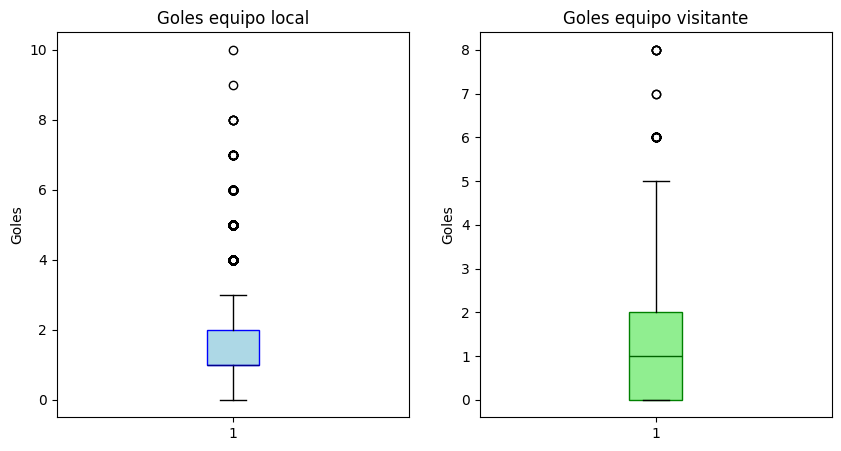

El script se ejecutó correctamente


In [407]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import config
import networkx as nx

def load_and_eda(file: str):
    """
    Carga el dataset y elimina columnas preestablecidas.

    Args:
        file (str): ruta relativa al dataset.

    Returns:
        pd.DataFrame: dataset cargado y personalizado.
    """
    data: pd.DataFrame = pd.read_csv(file)

    data = data.drop(columns=['HTHG', 'HTAG', 'HTR'])

    print(f'Las primeras y últimas filas del dataset son: \n')
    print(data.head(5))
    print(data.tail(5))

    print(f'\n\n El dataset contiene la siguiente información: \n')

    data.info()

    #Delvolvemos data para poder usarlo despues en la siguiente función
    return data


# Buscamos el archivo de datos (fuera de la función para despues llamarla)
file = os.path.join("data", "LaLiga_Matches.csv" )

# Llamamos a la función con el nombre de la ruta file
data = load_and_eda(file)

def plot_home_away_goals(data):
    """
    Figura con dos plots que muestra la distribución de goles marcados por equipos en casa y fuera

    Args:
      data: archivo de dataset limpio proveniente de la función load_and_eda

    Returns:
      plots
    """
    # Boxplot goles equipo local
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].boxplot(
        data['FTHG'],
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", color="blue"),
        medianprops=dict(color="darkblue")
    )
    axes[0].set_title('Goles equipo local')
    axes[0].set_ylabel('Goles')

    # Boxplot goles equipo visitante
    axes[1].boxplot(
        data['FTAG'],
        patch_artist=True,
        boxprops=dict(facecolor="lightgreen", color="green"),
        medianprops=dict(color="darkgreen")
    )
    axes[1].set_title('Goles equipo visitante')
    axes[1].set_ylabel('Goles')

    print('\nLa distribución de los goles es la siguiente:')
    
    plt.savefig(f"img/grafica_boxplot_exX_{config.nom_alumne}_{config.date_time}.png")
    plt.show()
    
    print(f'El script se ejecutó correctamente')

plot_home_away_goals(data)


# Ej 2. (0,6p) Partidos totales jugados

- define la función *total_matches(data)*, que devuelve un dataframe *matches_team_total* con el número de partdos
jugados por cada equipo durante todos los años.
- ejecuta la función y muestra los 10 primeros valores.
- muestra los equipos que siempre han estado en primera división (los que tienen el máximo número de partidos).
- define la función *plot_matches_team_total(matches_team_total)*, que representa esta información (eje
x: equipos; eje y: número de partidos total). Ejecuta la función.

In [408]:
def total_matches(data):
    """
    Función que devuelve el número de partidos jugados por cada equipo
    Args:
        dataset de las primeras funciones
    Returns:
        dataframe con columna equipo y número de partidos
    """
    #Contabilizamos los partidos de cada equipo tanto en casa como fuera
    home = data['HomeTeam'].value_counts()
    away = data['AwayTeam'].value_counts()

    #Realizamos la suma de ambos datasets anteriores y ordenamos de mayor a menor
    matches_team_total = home.add(away, fill_value = 0)
    matches_team_total = matches_team_total.sort_values(ascending=False)
    matches_team_total = matches_team_total.reset_index()
    matches_team_total.columns = ['Team', 'Matches']
    print("\nLos partidos totales de los 10 primeros equipos fueron:")
    print(matches_team_total.head(10))
    
    maximo = matches_team_total['Matches'].max()
    always_first_division = matches_team_total[matches_team_total['Matches'] == maximo]
    print(f'\n \n Los equipos que siempre jugaron en primera disión son: \n {always_first_division} ')


    return matches_team_total

In [409]:
matches_team_total = total_matches(data)
matches_team_total.head(10)


Los partidos totales de los 10 primeros equipos fueron:
          Team  Matches
0   Ath Bilbao     1158
1    Barcelona     1158
2  Real Madrid     1158
3     Valencia     1158
4   Ath Madrid     1082
5      Espanol     1082
6     Sociedad     1044
7      Sevilla     1044
8        Betis     1006
9        Celta      930

 
 Los equipos que siempre jugaron en primera disión son: 
           Team  Matches
0   Ath Bilbao     1158
1    Barcelona     1158
2  Real Madrid     1158
3     Valencia     1158 


,Team,Matches
0,Ath Bilbao,1158
1,Barcelona,1158
2,Real Madrid,1158
3,Valencia,1158
4,Ath Madrid,1082
5,Espanol,1082
6,Sociedad,1044
7,Sevilla,1044
8,Betis,1006
9,Celta,930


In [410]:
def plot_matches_team_total(matches_team_total):
    """"
    Grafico de barras para representar el número de partidos que jugó cada equipo

    Args:
        Matches_team_total: Dataset de la función total_matches (return)
    Returns:
        Gráfico que se guardará en la carpeta img
    """

    fig, ax2 = plt.subplots(figsize=(30, 10))
    
    ax2.bar(matches_team_total['Team'], 
            matches_team_total['Matches'], 
            color = 'skyblue')
    ax2.set_xlabel('Team')
    ax2.tick_params(axis='x', labelrotation=45)
    ax2.set_ylabel('Quantity of Matches')
    ax2.set_title('Matches per team in first division', fontsize = 20)
    
    plt.savefig(f"img/grafica_matches_team_total_exX_{config.nom_alumne}_{config.date_time}.png")
    plt.show
    
    print(f'El script se ejecutó correctamente y el gráfico se guardo en la carpeta img')

El script se ejecutó correctamente y el gráfico se guardo en la carpeta img


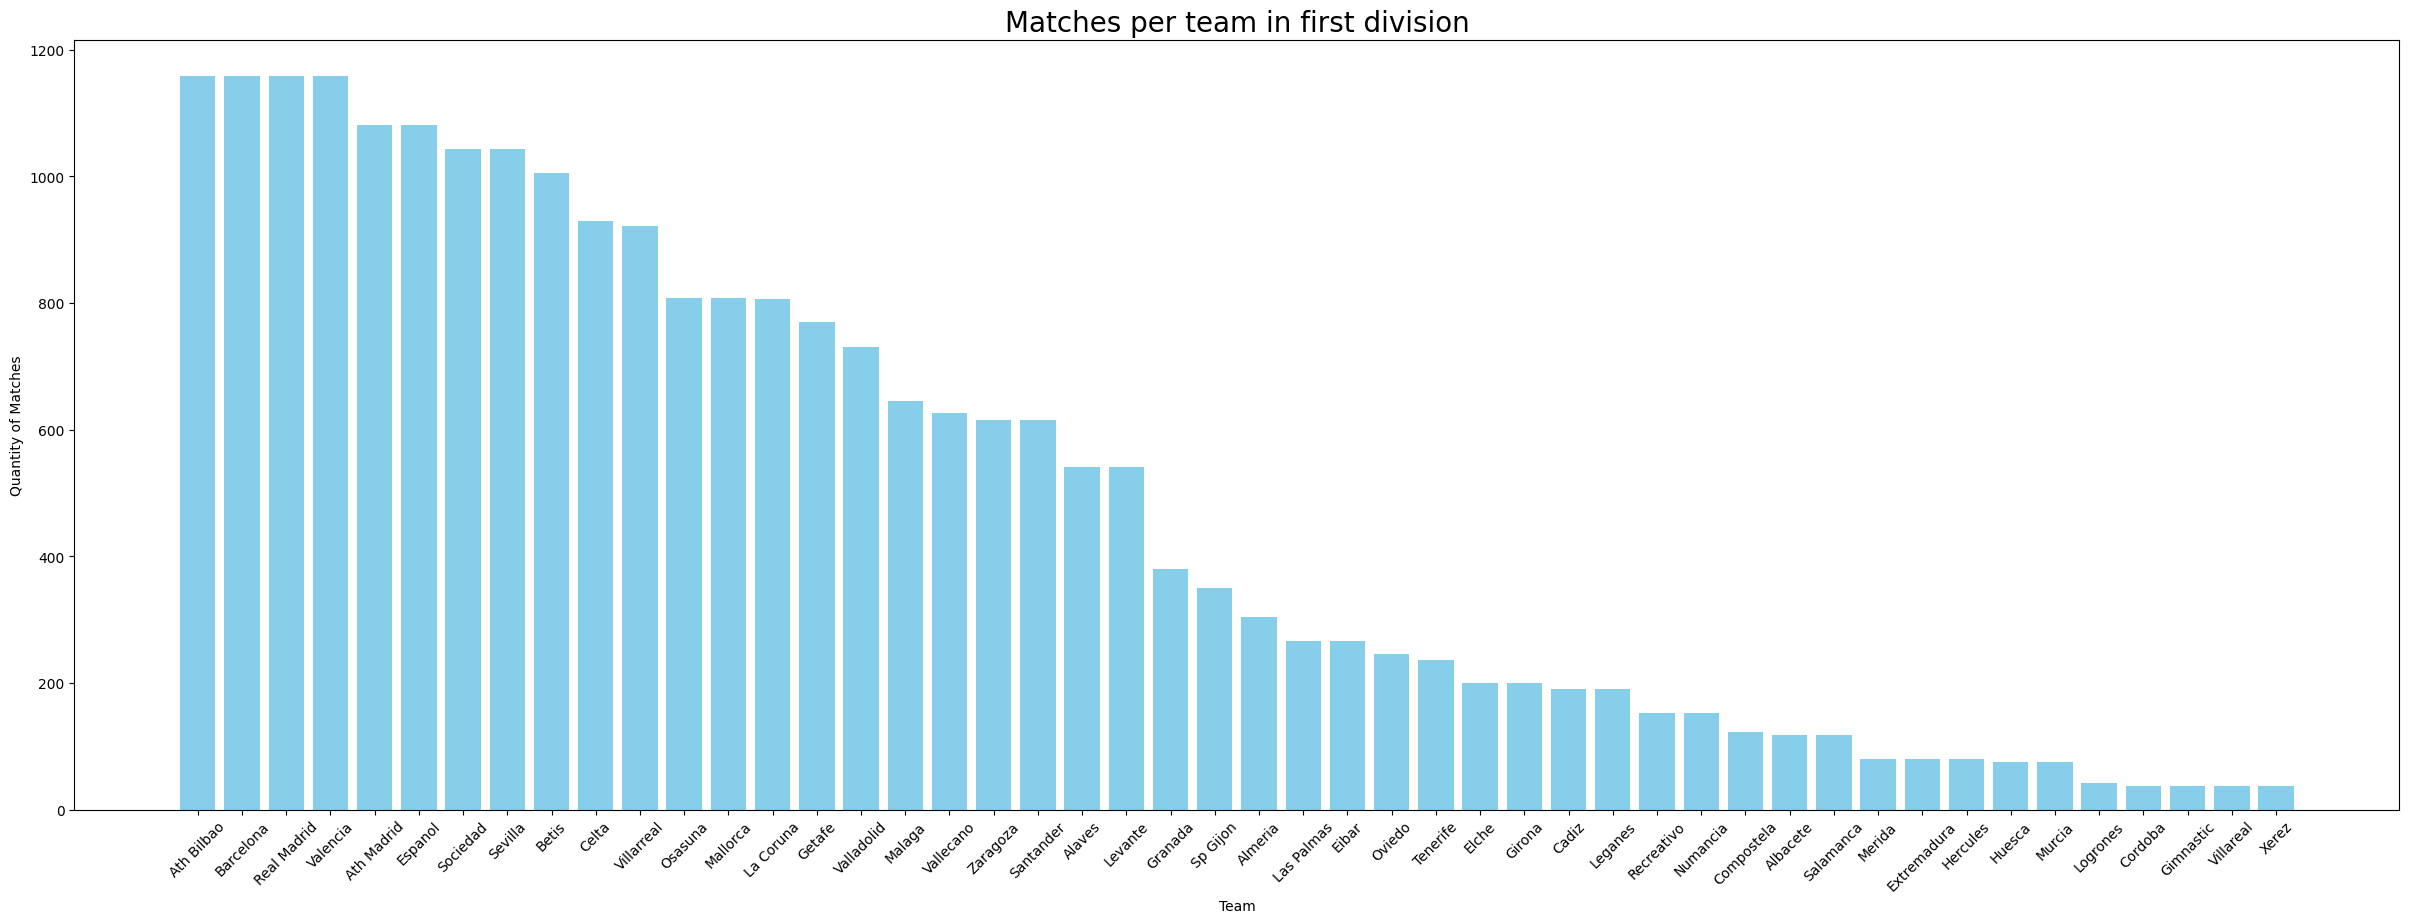

In [411]:
plot_matches_team_total(matches_team_total)

# Ej 3. (0,6p) Distribución de goles

- define la función *goals_distribution(data)*, que devuelve dos dataframes: *distr_goals_home*,
*distr_goals_away*. Estos dataframes contienen como índice el número de goles marcados (por ej, FTHG), y
como columna el número de partidos en que se han marcado este número de goles. Por ejemplo, hay 2598
partidos en que FTHG=0 (los equipos locales no marcaron ningún).
- ejecuta la función y muestra el dataframe resultante.
- define la función *plot_goals_ditribution(distr_goals_home, distr_goals_away)* para representar esta
información (una gráfica, dos plots). Ejecuta la función.

In [412]:
def goals_distribution(data):
    """
    Dataframes que contendrán como índice el número de goles marcados y como columna el número de partidos en que se han marcado este número de goles

    Args:
        Dataset de la función 1 limpio
    Returns:
        Dos dataframes con las matrices, uno para goles en casa y otro para goles fuera.
    """

    distr_goals_home = data['FTHG'].value_counts().sort_index().to_frame(name = 'Quantity of matches')
    distr_goals_away = data['FTAG'].value_counts().sort_index().to_frame(name = 'Quantity of matches')

    return distr_goals_home, distr_goals_away

In [413]:
distr_goals_home, distr_goals_away = goals_distribution(data)
print(distr_goals_home)
print(distr_goals_away)

      Quantity of matches
FTHG                     
0                    2598
1                    3864
2                    2834
3                    1416
4                     634
5                     223
6                      66
7                      22
8                       5
9                       1
10                      1
      Quantity of matches
FTAG                     
0                    3958
1                    4185
2                    2270
3                     843
4                     284
5                      93
6                      24
7                       2
8                       5


In [414]:
def plot_goals_distribution(distr_goals_home, distr_goals_away):
    """
    Representación gráfica de la distribución de goles 

    Args:
        Dataframes con las matrices de goles tanto en casa como de visitante
    Returns:
        Dos plots, uno para los goles en casa y otro para los goles como visitante
    """

    fig3, axes3 = plt.subplots(1,2, figsize = (10,9))

    axes3[0].bar(distr_goals_home.index, distr_goals_home['Quantity of matches'])
    axes3[0].set_title('Home Goals Distribution')
    axes3[0].set_xlabel('Goals')
    axes3[0].set_ylabel('Matches')

    axes3[1].bar(distr_goals_away.index, distr_goals_away['Quantity of matches'])
    axes3[1].set_title('Away Goals Distribution')
    axes3[1].set_xlabel('Goals')
    axes3[1].set_ylabel('Matches')

    plt.tight_layout()

    plt.savefig(f"img/grafica_goals_distribution_exX_{config.nom_alumne}_{config.date_time}.png")
    plt.show()

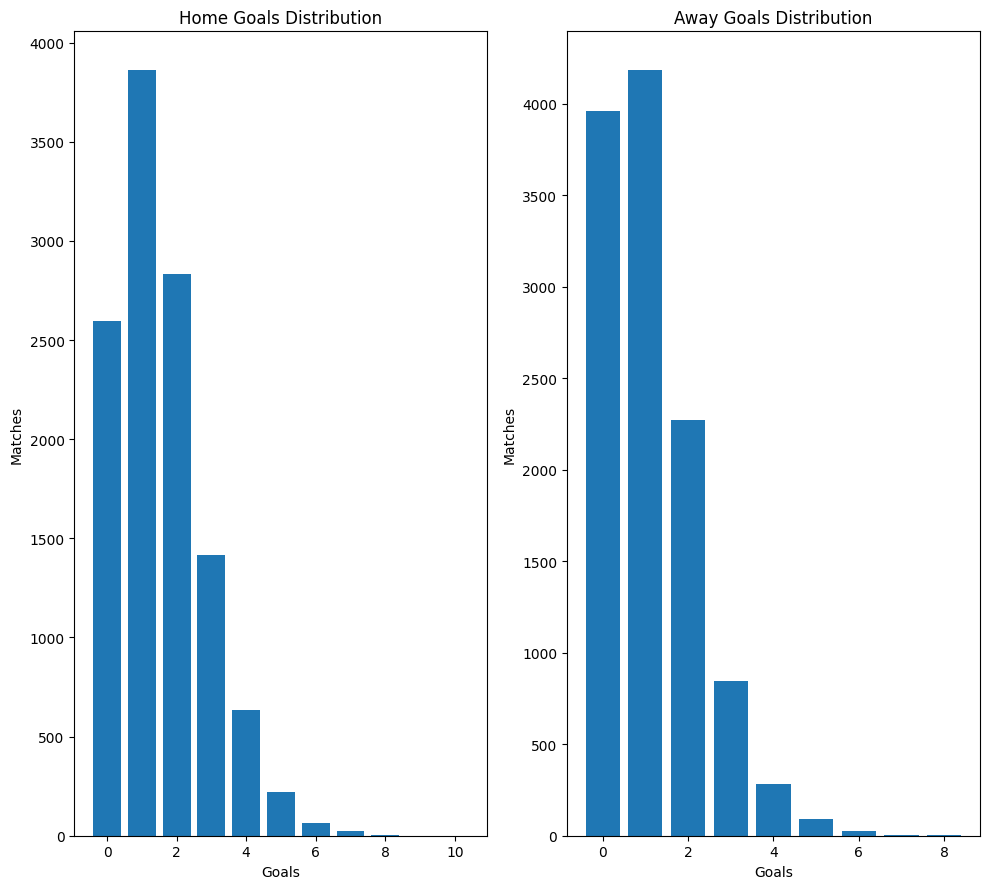

In [415]:
plot_goals_distribution(distr_goals_home, distr_goals_away)

# Ej 4. (0,6p) Partidos ganados en casa/fuera

- Define la función *FTR(data)*, que devuelve el número de partidos que han ganado los locales, que han
ganado los visitantes, o que han empatado (*draw*), en forma de dataframe (dataframe *ftr*).
- Ejecuta la función y muestra el dataframe resultante.
- ¿Qué porcentaje de partidos ganan los locales?
- Define la función *plot_FTR(ftr)* que representa esta información (eje x: H, A, D; eje y: número de partidos).
Executa la funció

In [416]:
def FTR(data):
    """
    Realizar conteo de partidos ganados por locales o visitantes o empatados

    Args:
        Dataframe data de la función 1
    Returns:
        Dataframe con esas tres posibilidades
    """
    contador_locales = 0
    contador_visitantes = 0
    contador_draw = 0

    for index, row in data.iterrows():

        if row['FTHG'] == row['FTAG']:
            contador_draw += 1

        elif row['FTHG'] > row['FTAG']:
            contador_locales += 1

        else:
            contador_visitantes += 1
            
    ftr_dict = {}

    ftr_dict = {
        'Resultado' : ['Victoria local', 'Victoria visitante', 'Empate'],
        'Número de partidos' : [contador_locales, contador_visitantes, contador_draw]
    }

    FTR = pd.DataFrame(ftr_dict)

    partidos_totales = FTR['Número de partidos'].sum()
    porcentaje_win_local = (contador_locales / partidos_totales)  *100
    print(f'El porcentaje de partidos que ganan los equiops locales es de {porcentaje_win_local:.2f} %')


    print(f'\n \n La función 4 se ejecutó correctamente y tenemos un dataframe con la contabilización de victorias locales, visitantes y empates\n \n')

    return FTR

In [417]:
ftr = FTR(data)
print(ftr)

El porcentaje de partidos que ganan los equiops locales es de 47.15 %

 
 La función 4 se ejecutó correctamente y tenemos un dataframe con la contabilización de victorias locales, visitantes y empates
 

            Resultado  Número de partidos
0      Victoria local                5500
1  Victoria visitante                3172
2              Empate                2992


In [418]:
def plot_FTR(ftr):
    """
    Representación de la información de la función FTR.

    Args:
        ftr (pd.DataFrame): dataframe proporcionado por la función FTR.
    """
    fig4, axes4 = plt.subplots(figsize=(10, 6))

    axes4.barh(ftr['Resultado'], ftr['Número de partidos'], color='skyblue')
    axes4.set_xlabel('Número de partidos')
    axes4.set_ylabel('Resultado')
    axes4.set_title('Distribución de resultados finales')

    plt.tight_layout()
    plt.savefig(f"img/grafica_Información_resultados_partidos_exX_{config.nom_alumne}_{config.date_time}.png")
    plt.show()

    return

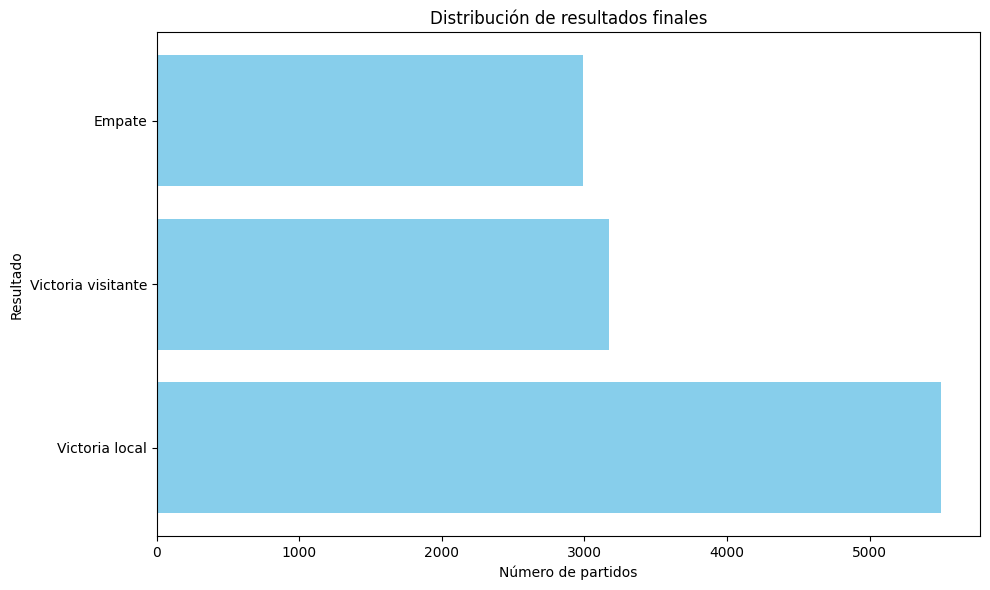

None


In [419]:
plot_FTR = plot_FTR(ftr)
print(plot_FTR)

# Ej 5. (0,6p) Clasificación global 1995-2025

- define la funció *add_points(data)*, que añade al dataset los punts conseguidos como local y como
visitante, por cada partido. Es decir, crea las columnas *points_home* y *points_away*, que pueden coger los valores de 3, 1 o 0.
- ejecuta la función y muestra los 10 primeros valores.
- define la funció *fun_total_points(data)*, que calcula el total de puntos conseguidos y acumulados desde 1995
por cada equipo. Devuelve por cada equipo el número de puntos totales, en forma de tupla: variable Series i
variable Dataframe (el Series y el Dataframe de hecho contienen la misma información). (Es una propuesta, un
alumno puede decidir que sólo devuelva la Series o el Dataframe).
- ejecuta la función y muestra los 10 primeros valores.
- define la función *alltime_winner(df_total_points)*, que devuelve el ganador de esta liga histórica y
acumulada (el equipo que ha acumulado más puntos). Ejecuta la función y muestra el ganador histórico.

In [420]:
def add_points(data):
    """
    Añadir al dataset original y limpio los puntos conseguidos en casa  o puntos fuera de casa

    Args:
        Dataset de la función 1 limpio
    Returns:
        Nuevo dataset con los puntos conseguidos por cada equipo
    """
    # Por defecto 0 (derrota)
    data['points_home'] = 0
    data['points_away'] = 0

    # Empate: 1 punto a cada uno
    empate = data['FTHG'] == data['FTAG']
    data.loc[empate, 'points_home'] = 1
    data.loc[empate, 'points_away'] = 1

    # Gana local: 3 al local
    gana_local = data['FTHG'] > data['FTAG']
    data.loc[gana_local, 'points_home'] = 3

    # Gana visitante: 3 al visitante
    gana_visitante = data['FTHG'] < data['FTAG']
    data.loc[gana_visitante, 'points_away'] = 3

    return data

In [421]:
data_2 = add_points(data)
data_2

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,points_home,points_away
0,1995-96,02-09-1995,La Coruna,Valencia,3,0,H,3,0
1,1995-96,02-09-1995,Sp Gijon,Albacete,3,0,H,3,0
2,1995-96,03-09-1995,Ath Bilbao,Santander,4,0,H,3,0
3,1995-96,03-09-1995,Ath Madrid,Sociedad,4,1,H,3,0
4,1995-96,03-09-1995,Celta,Compostela,0,1,A,0,3
...,...,...,...,...,...,...,...,...,...
11659,2025-26,26-10-2025,Mallorca,Levante,1,1,D,1,1
11660,2025-26,26-10-2025,Real Madrid,Barcelona,2,1,H,3,0
11661,2025-26,26-10-2025,Osasuna,Celta,2,3,A,0,3
11662,2025-26,26-10-2025,Vallecano,Alaves,1,0,H,3,0


In [422]:
def fun_total_points(data):
    """
    Calcula el total de puntos acumulados por cada equipo desde 1995.

    Args:
        data: dataset con points_home y points_away.

    Returns:
        tuple[pd.Series, pd.DataFrame]: misma información en dos formatos.
    """
    puntos_local = data.groupby('HomeTeam')['points_home'].sum()
    puntos_visitante = data.groupby('AwayTeam')['points_away'].sum()

    total= puntos_local.add(puntos_visitante, fill_value=0)
    total = total.sort_values(ascending=False)
    total.name = 'TotalPoints'

    df_total_points = total.reset_index()
    df_total_points.columns = ['Team', 'TotalPoints']

    return total, df_total_points

In [423]:
series_points, df_points = fun_total_points(data_2)
df_points.head(10)

,Team,TotalPoints
0,Barcelona,2483
1,Real Madrid,2458
2,Ath Madrid,1898
3,Valencia,1812
4,Ath Bilbao,1631
5,Sevilla,1572
6,Sociedad,1464
7,Villarreal,1423
8,Betis,1369
9,Espanol,1354


In [424]:
def alltime_winner(df_total_points):
    """
    Devuelve el equipo con más puntos acumulados de toda la historia.

    Args:
        df_total_points: puntos totales por equipo.

    Returns:
        pd.Series: fila del equipo ganador.
    """
    ganador = df_total_points.loc[df_total_points['TotalPoints'].idxmax()]
    return ganador

In [425]:
ganador_histórico = alltime_winner(df_points)
ganador_histórico

Team           Barcelona
TotalPoints         2483
Name: 0, dtype: object

# Ej 6. (0,6p) Dataframe summary_1995_2025. Podium.

- Define la función *fun_total_goals(data)*, que devuelve una tupla de tres números enteros: (*home_goals*,
*away_goals*, *total_goals*). Muestra esta información.
- Define la función *fun_total_goals_by_team(data)*, que devuelve una tupla de tres dataframes:
*home_goals_by_team*, *away_goals_by_team*, *total_goals_by_team*. Muestra los 10 primeros valores de
*total_goals_by_team*.
- En el ejercicio 5 calculaste el número total de puntos por equipo: `total_points_by_team, df_total_points_by_team = fun_total_points(data)`
- Define la función *fun_summary_1996_2025( , , , )* que crea el dataframe *summary_1996_2025* a partir de la
concatenación de los 4 dataframes que pasamos como argumentos: *total_points_by_team*, *home_goals_by_team*, *away_goals_by_team*, *total_goals_by_team*.
- Ejecuta la función y muestra los primeros valores.
- Define la función *podium(summary_1996_2025)*, que crea una gráfica de podium a partir de un dataframe donde los tres primeros valores son los equipos que componen el podium. La forma de podium se puede conseguir con un diagrama de barras, cada barra con un color, donde el primer equipo está enmedio, el segundo a la izquierda a menor altura, y el tercero a la derecha a menor altura, sin etiquetas en los ejes. Sobre cada barra pondréis el nombre del equipo.
- Ejecuta la función.

In [426]:
def fun_total_goals(data):
    """
    Devuelve los goles totales marcados como local, como visitante y en total.

    Args:
        data (pd.DataFrame): dataset de partidos.

    Returns:
        tuple[int, int, int]: (home_goals, away_goals, total_goals).
    """

    home_goals = int(data['FTHG'].sum())
    away_goals = int(data['FTAG'].sum())
    total_goals = home_goals + away_goals

    return home_goals, away_goals, total_goals

In [427]:
home_goals, away_goals, total_goals = fun_total_goals(data_2)
print(f"Goles local: {home_goals}, visitante: {away_goals}, total: {total_goals}")

Goles local: 18040, visitante: 13053, total: 31093


In [428]:
def fun_total_goals_by_team(data):
    """
    Goles marcados por cada equipo como local, como visitante y en total.

    Args:
        data (pd.DataFrame): dataset de partidos.

    Returns:
        tuple de tres DataFrames: home, away y total de goles por equipo.
    """
    home = data.groupby('HomeTeam')['FTHG'].sum()
    away = data.groupby('AwayTeam')['FTAG'].sum()
    total = home.add(away, fill_value=0).astype(int)

    home_goals_by_team = home.sort_values(ascending=False).reset_index()
    home_goals_by_team.columns = ['Team', 'HomeGoals']

    away_goals_by_team = away.sort_values(ascending=False).reset_index()
    away_goals_by_team.columns = ['Team', 'AwayGoals']

    total_goals_by_team = total.sort_values(ascending=False).reset_index()
    total_goals_by_team.columns = ['Team', 'TotalGoals']

    return home_goals_by_team, away_goals_by_team, total_goals_by_team

In [429]:
home_goals_by_team, away_goals_by_team, total_goals_by_team = fun_total_goals_by_team(data_2)
total_goals_by_team.head(10)

,Team,TotalGoals
0,Barcelona,2656
1,Real Madrid,2542
2,Ath Madrid,1747
3,Valencia,1706
4,Ath Bilbao,1516
5,Sevilla,1489
6,Sociedad,1396
7,Villarreal,1350
8,Betis,1288
9,Espanol,1270


In [430]:
def fun_summary_1996_2025(total_points_by_team, home_goals_by_team, away_goals_by_team, total_goals_by_team):
    """
    Concatena los cuatro DataFrames (puntos, goles local, goles visitante,
    goles totales) en un único resumen por equipo.

    Returns:
        pd.DataFrame: resumen combinado, ordenado por puntos.
    """
    summary = pd.concat(
        [
            total_points_by_team.set_index('Team'),
            home_goals_by_team.set_index('Team'),
            away_goals_by_team.set_index('Team'),
            total_goals_by_team.set_index('Team'),
        ],
        axis=1
    )

    summary = summary.sort_values('TotalPoints', ascending=False).reset_index()

    return summary

In [431]:
summary_1996_2025 = fun_summary_1996_2025(df_points,home_goals_by_team,away_goals_by_team,total_goals_by_team)
summary_1996_2025.head()

,Team,TotalPoints,HomeGoals,AwayGoals,TotalGoals
0,Barcelona,2483,1525,1131,2656
1,Real Madrid,2458,1474,1068,2542
2,Ath Madrid,1898,1026,721,1747
3,Valencia,1812,1003,703,1706
4,Ath Bilbao,1631,890,626,1516


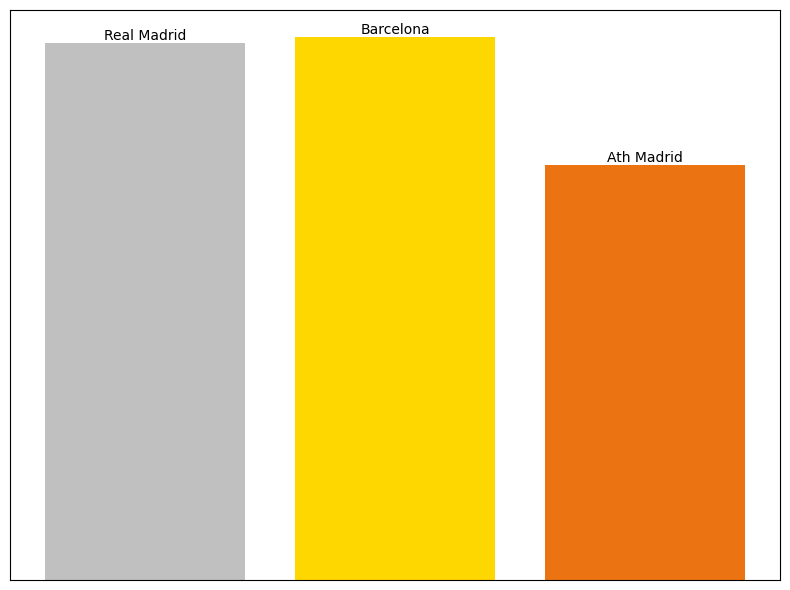

In [432]:
def podium(summary_1996_2025):
    """
    Dibuja un podio con los tres primeros equipos del resumen.

    Args:
        summary_1996_2025 (pd.DataFrame): resumen ordenado por puntos.
    """
    top3 = summary_1996_2025.head(3)

    equipos = top3['Team'].tolist()
    puntos = top3['TotalPoints'].tolist()

    # Orden visual: 2º a la izquierda, 1º en el centro, 3º a la derecha
    posiciones = [0, 1, 2]
    alturas = [puntos[1], puntos[0], puntos[2]]
    nombres = [equipos[1], equipos[0], equipos[2]]
    colores = ['silver', 'gold', "#eb7311"]  

    fig, ax = plt.subplots(figsize=(8, 6))
    barras = ax.bar(posiciones, alturas, color=colores)

    # Nombre del equipo encima de cada barra
    for barra, nombre in zip(barras, nombres):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height(),
            nombre,
            ha='center', va='bottom'
        )

    # Sin etiquetas en los ejes
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig(f"img/grafica_exX_{config.nom_alumne}_{config.date_time}.png")
    plt.show()


podium(summary_1996_2025)

# Ej 7. (0,6p) Grafo

- Define la función *graf(data, selected_teams)*, donde *data* es el dataset y *selected_teams* es una lista de los 5 equipos que han conseguido mejor puntuación acumulada. Filtrarás el dataset con las filas que el equipo local y el equipo visitante estén en la lista de seleccionados. Con la librería *networkx* puedes hacer un grafo de conexiones. Por ejemplo, entre *Ath Bilbao* y *Real Madrid* hay 30+30 conexiones (Ath Bilbao ha jugado 30 veces como local y 30 veces como visitante). Puedes crear dos flechas, o bien agruparlo y poner una línea sin flecha que una Ath Bilbao y Real Madrid. Al lado de la línea tiene que haber el número de conexiones.
- Ejecuta la función y genera el grafo.


In [ ]:
def graf(data, selected_teams):
    """
    Dibujar un grafo de conexiones entre los equipos seleccionados, donde
    cada artista indica cuántas veces se han enfrentado (local + visitante).

    Args:
        data (pd.DataFrame): dataset de partidos.
        selected_teams (list[str]): lista de equipos a incluir.
    """
    # 1. Filtramos: local Y visitante deben estar en la lista
    mask = data['HomeTeam'].isin(selected_teams) & data['AwayTeam'].isin(selected_teams)
    subset = data[mask]

    # 2. Contamos enfrentamientos por pareja, sin importar quién jugó en casa
    conexiones: dict[frozenset, int] = {}
    for _, row in subset.iterrows():
        pareja = frozenset([row['HomeTeam'], row['AwayTeam']])
        # frozenset ignora el orden: {A,B} == {B,A}
        if len(pareja) == 2:  # descarta un improbable equipo contra sí mismo
            conexiones[pareja] = conexiones.get(pareja, 0) + 1

    # 3. Construimos el grafo
    G = nx.Graph()
    G.add_nodes_from(selected_teams)
    for pareja, n in conexiones.items():
        equipo_a, equipo_b = tuple(pareja)
        G.add_edge(equipo_a, equipo_b, weight=n)

    # 4. Dibujamos
    fig, ax = plt.subplots(figsize=(10, 8))
    pos = nx.circular_layout(G)  # coloca los nodos en círculo

    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2500, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
    nx.draw_networkx_edges(G, pos, ax=ax)

    # Número de conexiones sobre cada línea
    edge_labels = {(a, b): d['weight'] for a, b, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax)

    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f"img/grafica_grafo_exX_{config.nom_alumne}_{config.date_time}.png")
    plt.show()

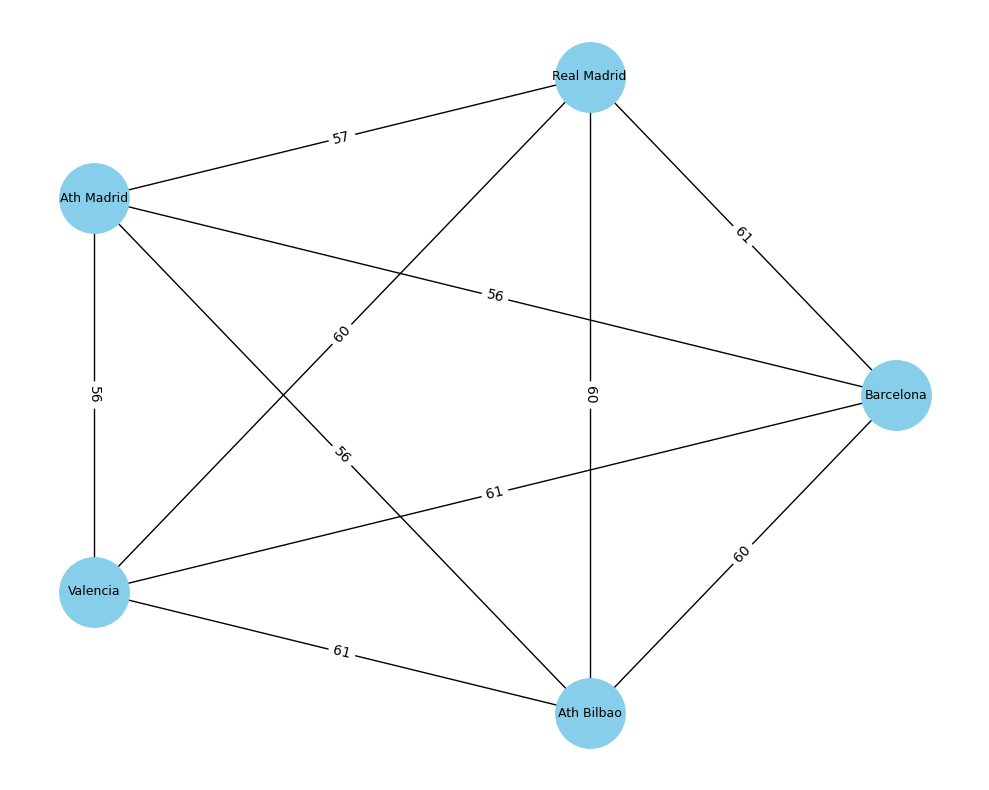

In [ ]:
selected_teams = df_points['Team'].head(5).tolist()
graf(data_2, selected_teams)

<!-- # Ej 8 (2p). Proyecto Python. Organización del código. Modularidad. Capturas de pantalla

Una vez hayas conseguido la funcionalidad de los 7 primeros ejercicios, insistimos ahora en cómo tienes que organizar el código. La estructura del proyecto tiene que ser:

<pre>
- src/
   - main.py: Fichero principal. Ejecuta los diferentes ejercicios de la PEC.
   - exercises/: contiene las funciones de los diferentes ejercicios.
     - ex1.py, etc: Contiene las funciones que definimos en el ejercicio 1, etc.
     - ...
   - data/: el dataset
   - img/: imágenes generadas
- tests/:
   - tests_ex6.py: sólo se te pedirá test sobre el ejercicio 6
- doc/: documentación generada
- screenshots/: contiene capturas de pantalla donde se comprueba la autoría de la PAC.
- requirements.txt: librerías necesarias
- README.md: Información sobre el proyecto, cómo ejecutarlo, cómo comprobar el linting,
generar la documentación y ejecutar los tests.
- LICENSE: fichero de licencia
</pre>

En el fichero *main.py* se importarán como módulos las funcionalidades de los diferentes ejercicios. La idea es que toda la funcionalidad esté en los módulos, y el fichero *main.py* sirva como punto de entrada para leer las opciones y ejecutar los módulos/ejercicios.

Se ejecutará de forma secuencial lo que se pida en los diferentes ejercicios . El fichero *main.py* admite el argumento *-h/--help* de ayuda, y el argumento *-ex* para ejecutar los ejercicios de forma incremental. Se entiende que para ejecutar el ejercicio 5 se han de ejecutar previamente los 4 primeros ejercicios. Así pues, *python main.py -ex 5* significa ejecutar los 5 primers exercicis. Puedes utilizar directamente la librería *sys*, o bien alguna otra posibilidad (*getopt* o *argparse*, que es la que se utiliza en la solución).

Los diferentes *prints()* que se piden estarán en el *main.py* (de manera que en los módulos/ejercicios sólo habrá la definición de las funciones). Se pide una captura de pantalla de la estructura de carpeta, donde se vea vuestro nombre, y captura de pantalla de cómo has ejecutado correctamente el proyecto.

**NOTA**: los diferentes módulos sólo incluirán estrictamente las librerías necesarias (el proceso de linting os informará de las librerías sobrantes). -->

# Ej 8 (2p). Proyecto Python. Organización del código. Modularidad. Capturas de pantalla

Una vez hayas conseguido la funcionalidad de los 7 primeros ejercicios, insistimos ahora en cómo tienes que organizar el código. La estructura del proyecto tiene que ser:

<pre>
- src/
   - main.py: Fichero principal. Ejecuta los diferentes ejercicios de la PEC.
   - exercises/: contiene las funciones de los diferentes ejercicios.
     - ex1.py, etc: Contiene las funciones que definimos en el ejercicio 1, etc.
     - ...
   - data/: el dataset
   - img/: imágenes generadas
- tests/:
   - tests_ex6.py: sólo se te pedirá test sobre el ejercicio 6
- doc/: documentación generada
- screenshots/: contiene capturas de pantalla donde se comprueba la autoría de la PAC.
- requirements.txt: librerías necesarias
- README.md: Información sobre el proyecto, cómo ejecutarlo, cómo comprobar el linting,
generar la documentación y ejecutar los tests.
- LICENSE: fichero de licencia
</pre>

En el fichero *main.py* se importarán como módulos las funcionalidades de los diferentes ejercicios. La idea es que toda la funcionalidad esté en los módulos, y el fichero *main.py* sirva como punto de entrada para leer las opciones y ejecutar los módulos/ejercicios.

Se ejecutará de forma secuencial lo que se pida en los diferentes ejercicios . El fichero *main.py* admite el argumento *-h/--help* de ayuda, y el argumento *-ex* para ejecutar los ejercicios de forma incremental. Se entiende que para ejecutar el ejercicio 5 se han de ejecutar previamente los 4 primeros ejercicios. Así pues, *python main.py -ex 5* significa ejecutar los 5 primers exercicis. Puedes utilizar directamente la librería *sys*, o bien alguna otra posibilidad (*getopt* o *argparse*, que es la que se utiliza en la solución).

Los diferentes *prints()* que se piden estarán en el *main.py* (de manera que en los módulos/ejercicios sólo habrá la definición de las funciones). Se pide una captura de pantalla de la estructura de carpeta, donde se vea vuestro nombre, y captura de pantalla de cómo has ejecutado correctamente el proyecto.

**NOTA**: los diferentes módulos sólo incluirán estrictamente las librerías necesarias (el proceso de linting os informará de las librerías sobrantes).

Ejecutado con éxito

# Ej 9 (0,5p). Linter con Pylint

El código tiene que seguir la guía de estilo de Python (PEP8), exceptuando los casos en que hacerlo complique la legibilidad del código. Haz el análisis estático del código con pylint y limpia los errores de estilo. Se puede utilizar *.pylintrc* para adaptarlo a vuestro criterio. Importante poner en el *README* cómo se comprueba el linting. Captura de pantalla de la comprobación del linting, donde se vea vuestro nombre (no es preciso conseguir un 10, según vuestro criterio).

Ejecutado con éxito

# Ej 10 (1p). Documentación

Generad la documentación con *pydoc* (o alguna otra librería si lo consideráis más apropiada). Todas las funciones han de tener *docstrings*. La carpeta *doc/* estará en la raíz del proyecto. Importante poner en el *README* cómo se genera la documentación. Captura de pantalla de la documentación, donde se vea vuestro nombre.

Ejecutado con éxito

# Ej 11 (1p). Tests

Se pide un solo test que servirá para comprobar el funcionamiento correcto de la función *fun_total_goals*
definida en el ejercicio 6. Importante poner en el *README* cómo se ejecutan los tests. Captura de pantalla de la
execució del test en vuestra máquina, y donde se vea vuestro nombre.

Si tenéis más tiempo se puede hacer una suite de tests más completa y hacer un informe de la cobertura de vuestra suite de tests.

# Ej 12 (1,5p). README.md, requirements.txt, LICENSE

Incluirás el fichero *README* (formato txt o markdown) con la siguiente información:

- vuestro nombre y título del proyecto
- estructura y organización de carpetas
- instalación del proyecto a partir de *requirements.txt*, en un entorn venv limpio.
- ejecució del proyecto
- comprobación del análisis estático (linting)
- generación de la documentación
- comprobación de los tests
- ficheros *requirements.txt* (incluir sólo las librerías asociadas al proyecto, no es preciso las librerías asociadas al linting, documentación, tests) y *LICENCE* (licencia bajo la que se distribuye el código, podéis escoger la que queráis).
- Comandos para subir el proyecto a Github.

Este fichero es el primero que mirará el profesor a la hora de corregir, y espera encontrar una información clara y completa.

Tendréis que entregar un zip con el contenido del proyecto, siguiendo la estructura de carpetas que se propone.

**NOTA**: no incluir en el fichero de entrega las carpetas *.venv* o similares que ocupan mucho espacio. El proyecto no debería ocupar más de 5 MB (en función de las imágenes y capturas).


# Rúbrica


### Funcionalidad (4 p)

* Ejercicio 1 (0,4 p)
* Ejercicio 2 (0,6 p)
* Ejercicio 3 (0,6 p)
* Ejercicio 4 (0,6 p)
* Ejercicio 5 (0,6 p)
* Ejercicio 6 (0,6 p)
* Ejercicio 7 (0,6 p)

### Aspectos formales del proyecto Python (6 p)

* Proyecto Python. Organización del código. Modularidad (1,5 p)
* Capturas de pantalla, carpeta img/ (0,5p)
* Linter con Pylint (1 p)
* Documentación (1 p)
* Tests (1 p)
* README.md, requirements.txt, LICENSE (1 p)